<a href="https://colab.research.google.com/github/AnthonyMath1022/AnthonyMath1022/blob/main/Retail_Analysis_VAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')
%load_ext cudf.pandas
print('Loading data...')
train_path = '/content/drive/MyDrive/Reatilforecast/src/train.csv'
train_df = pd.read_csv(train_path, low_memory=True)
train_df['date'] = pd.to_datetime(train_df['date'])
pd.set_option('display.max_columns', 10)
display(train_df)


Mounted at /content/drive
Loading data...


/tmp/ipython-input-2450478014.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_path, low_memory=True)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


In [ ]:
start_date = '2017-07-01'
end_date = '2017-12-31'

train_df = train_df[(train_df['date'] >= start_date) & (train_df['date'] <= end_date)]
pd.set_option('display.max_columns', 10)
display(train_df)
train_df.count()
train_df.isna().sum()


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
120642911,120642911,2017-07-01,1,99197,2.0,False
120642912,120642912,2017-07-01,1,103520,2.0,False
120642913,120642913,2017-07-01,1,103665,11.0,False
120642914,120642914,2017-07-01,1,105574,2.0,False
120642915,120642915,2017-07-01,1,105575,3.0,False
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [ ]:
import pandas as pd

item_path = '/content/drive/MyDrive/Reatilforecast/src/items.csv'
store_path = '/content/drive/MyDrive/Reatilforecast/src/stores.csv'
oil_path = '/content/drive/MyDrive/Reatilforecast/src/oil.csv'

item = pd.read_csv(item_path)
store = pd.read_csv(store_path)
oil = pd.read_csv(oil_path )
oil = oil[(oil['date'] >= start_date) & (oil['date'] <= end_date)]

train_df = pd.merge(train_df,item,on='item_nbr',how='left')
train_df = pd.merge(train_df,store,on='store_nbr',how='left')
train_df.isna().sum()

id             0
date           0
store_nbr      0
item_nbr       0
unit_sales     0
onpromotion    0
family         0
class          0
perishable     0
city           0
state          0
type           0
cluster        0
dtype: int64

In [ ]:
import numpy as np

def most_frequent_sales(data, variable, N, all='TRUE'):


    # counts
    values, counts = np.unique(data[variable].to_numpy(), return_counts=True)

    # Ensure values and counts are 2D column vectors before stacking
    values_2d = values.reshape(-1, 1)
    counts_2d = counts.reshape(-1, 1)

    # Nx2 table: [value, count]
    labels_freq_pd = np.column_stack((values_2d, counts_2d))

    # sort by count desc
    labels_freq_pd = labels_freq_pd[np.argsort(labels_freq_pd[:, 1])[::-1]]

    # keep top N
    topN = labels_freq_pd[:N]
    main_labels = topN[:, 0] if all == 'False' else labels_freq_pd[:, 0]

    # raw labels (replace deprecated as_matrix)
    labels_raw_np = data[variable].to_numpy().reshape(-1, 1)

    # indices where label in main_labels (same style as your labels_filtered_index[0])
    labels_filtered_index = np.where(np.isin(labels_raw_np.ravel(), main_labels))

    return topN, labels_filtered_index

label_freq, labels_filtered_index = most_frequent_sales(train_df, 'item_nbr', 5, 'FALSE')
print("pd_train.shape=", labels_filtered_index[0].shape)

pd_train_filtered = train_df.loc[labels_filtered_index[0], :]
print("pd_train_filtered.shape = ", pd_train_filtered.shape)


pd_train.shape= (4854129,)
pd_train_filtered.shape =  (4854129, 13)


In [ ]:
pd_train_filtered  = pd_train_filtered.drop(['city','state','type','cluster','store_nbr','item_nbr','family','class','id'], axis = 1)

In [ ]:

dummy_variables = ['onpromotion','perishable']

for var in dummy_variables:
    dummy = pd.get_dummies(pd_train_filtered [var], prefix = var, drop_first = False).astype(int)
    pd_train_filtered  = pd.concat([pd_train_filtered ,dummy], axis = 1)

pd_train_filtered  = pd_train_filtered.drop(dummy_variables, axis = 1)


In [ ]:
import pandas as pd

# 1. Ensure your date columns are actual datetime objects
pd_train_filtered ['date'] = pd.to_datetime(pd_train_filtered ['date'])
oil['date'] = pd.to_datetime(oil['date'])

# 2. Generate the complete date range automatically
# pd.date_range replaces the manual loop and delta calculation
calendar = pd.DataFrame({
    'date': pd.date_range(start=train_df.date.min(), end=train_df.date.max())
})

# 3. Merge
oil = calendar.merge(oil, on='date', how='left')

In [ ]:
na_index_oil = oil[oil['dcoilwtico'].isnull() == True].index.values

#Define the index to use to apply the formala
na_index_oil_plus = na_index_oil.copy()
na_index_oil_minus = np.maximum(0, na_index_oil-1)

for i in range(len(na_index_oil)):
    k = 1
    while (na_index_oil[min(i+k,len(na_index_oil)-1)] == na_index_oil[i]+k):
        k += 1
    na_index_oil_plus[i] = min(len(oil)-1, na_index_oil_plus[i] + k )

#Apply the formula
for i in range(len(na_index_oil)):
    if (na_index_oil[i] == 0):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_plus[i], 'dcoilwtico']
    elif (na_index_oil[i] == len(oil)):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_minus[i], 'dcoilwtico']
    else:
        oil.loc[na_index_oil[i], 'dcoilwtico'] = (oil.loc[na_index_oil_plus[i], 'dcoilwtico'] + oil.loc[na_index_oil_minus[i], 'dcoilwtico'])/ 2

pd_train_filtered  = pd_train_filtered.merge(oil, left_on='date', right_on='date', how='left')


In [ ]:
pd_train_filtered.sample(10)

,date,unit_sales,onpromotion_False,onpromotion_True,perishable_0,perishable_1,dcoilwtico
599798,2017-07-06,1.000,1,0,0,1,45.520
3834513,2017-08-06,11.000,1,0,0,1,49.420
1266851,2017-07-12,3.000,1,0,1,0,45.480
4678330,2017-08-14,1.000,0,1,1,0,47.590
548200,2017-07-05,1.000,1,0,1,0,45.110
3538334,2017-08-03,4.000,1,0,0,1,49.030
2009182,2017-07-19,6.000,1,0,1,0,47.100
3481797,2017-08-02,21.000,1,0,0,1,49.600
2987192,2017-07-29,3.000,1,0,1,0,49.965
2020079,2017-07-19,4.535,1,0,0,1,47.100


In [ ]:
pd_train_filtered.count()

date                 4854129
unit_sales           4854129
onpromotion_False    4854129
onpromotion_True     4854129
perishable_0         4854129
perishable_1         4854129
dcoilwtico           4854129
dtype: int64

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

TOP_N = 10

# 1. Filter for Top 10 Items
# We use a wider date range (from Jan 2017) to ensure enough data for lookback and splitting.
local_start_date = '2017-01-01'

temp_base_df = pd.read_csv(train_path, low_memory=True)
temp_base_df['date'] = pd.to_datetime(temp_base_df['date'])
temp_base_df = temp_base_df[(temp_base_df['date'] >= local_start_date) & (temp_base_df['date'] <= end_date)].copy()

# Re-merge with item and store data
temp_item_df = pd.read_csv(item_path)
temp_store_df = pd.read_csv(store_path)
temp_base_df = pd.merge(temp_base_df, temp_item_df, on='item_nbr', how='left')
temp_base_df = pd.merge(temp_base_df, temp_store_df, on='store_nbr', how='left')

# Reload and merge Oil data (full range to cover Jan-July)
oil_full = pd.read_csv(oil_path)
oil_full['date'] = pd.to_datetime(oil_full['date'])
temp_base_df = pd.merge(temp_base_df, oil_full[['date', 'dcoilwtico']], on='date', how='left')

# Top 10 items
top_items = temp_base_df['item_nbr'].value_counts().head(TOP_N).index
pd_train_filtered = temp_base_df[temp_base_df['item_nbr'].isin(top_items)].copy()

# 2. Pivot the Data to Wide Format
# Sales Pivot
pivoted_sales = pd_train_filtered.pivot_table(
    index='date',
    columns='item_nbr',
    values='unit_sales',
    fill_value=0
)
pivoted_sales.columns = [f'sales_{i}' for i in pivoted_sales.columns]

# Promotion Pivot
if 'onpromotion' in pd_train_filtered.columns:
    pd_train_filtered['onpromotion'] = pd_train_filtered['onpromotion'].astype(int)
    pivoted_promo = pd_train_filtered.pivot_table(
        index='date',
        columns='item_nbr',
        values='onpromotion',
        fill_value=0
    )
    pivoted_promo.columns = [f'promo_{i}' for i in pivoted_promo.columns]
else:
    pivoted_promo = pd.DataFrame()

# Oil Data (Common Feature)
oil_series = pd_train_filtered.groupby('date')['dcoilwtico'].max()

# 3. Combine into one Wide Dataframe
combined = pd.concat([pivoted_sales, pivoted_promo, oil_series], axis=1)

# Fill gaps
combined = combined.ffill().bfill()

# Define targets and features
stock_cols = pivoted_sales.columns.tolist()
print(f"Target Columns ({len(stock_cols)}): {stock_cols}")
print(f"Total Features: {combined.shape[1]}")
print(f"Total Data Points (Days): {len(combined)}")

# --- TRAIN/TEST SPLIT ---
# Adjusted test_len to 16 days (typical for this dataset's horizon)
test_len = 16
trainval = combined.iloc[:-test_len]
test_data = combined.iloc[-test_len:]

val_len = int(len(trainval) * 0.2)
train_len = len(trainval) - val_len

train_data = trainval.iloc[:train_len]
val_data = trainval.iloc[train_len:]

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

# Scaling
feat_scaler = MinMaxScaler()
feat_scaler.fit(train_data.values)

train_scaled = feat_scaler.transform(train_data.values)
val_scaled = feat_scaler.transform(val_data.values)
test_scaled = feat_scaler.transform(test_data.values)

/usr/local/lib/python3.12/dist-packages/cudf/pandas/fast_slow_proxy.py:28: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  return fn(*args, **kwargs)


Target Columns (10): ['sales_222879', 'sales_261052', 'sales_265559', 'sales_314384', 'sales_323013', 'sales_364606', 'sales_502331', 'sales_1052563', 'sales_1157564', 'sales_1162382']
Total Features: 21
Total Data Points (Days): 227
Train size: 169, Val size: 42, Test size: 16


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

def choose_var_order(data, p_max=50):
    aic_tbl = {}
    for p in range(1, p_max + 1):
        try:
            res = VAR(data).fit(p)
            aic_tbl[p] = res.aic
            print(f"VAR({p}): AIC = {res.bic:.2f}")
        except np.linalg.LinAlgError as e:
            print(f"VAR({p}): LinAlgError – {e}")
        except ValueError as e:
            print(f"VAR({p}): ValueError – {e}")
    if not aic_tbl:
        raise RuntimeError("No VAR(p) model converged up to p_max")
    best_p = min(aic_tbl, key=aic_tbl.get)
    print("="*72)
    print(f"Best lag order by AIC: VAR({best_p})  (AIC={aic_tbl[best_p]:.2f})")
    return best_p, aic_tbl

In [ ]:
best_p, aic_table = choose_var_order(train_scaled, p_max=20)
var_res = VAR(train_scaled).fit(best_p)
print(var_res.summary())

Streaming output truncated to the last 5000 lines.
L1.y20         -0.006223         0.000000     -1466087.211           0.000
L1.y21          0.275327         0.000000     94457403.378           0.000
L2.y1           0.053244         0.000000      2537041.981           0.000
L2.y2           0.251482         0.000000     28720917.037           0.000
L2.y3          -0.337768              NAN              NAN             NAN
L2.y4          -0.128783         0.000000    -11325309.144           0.000
L2.y5           0.124260         0.000000     28369160.000           0.000
L2.y6           0.015647         0.000000       468610.906           0.000
L2.y7          -0.072743              NAN              NAN             NAN
L2.y8           0.022945         0.000000      1992813.315           0.000
L2.y9          -0.091890         0.000000     -5105614.886           0.000
L2.y10         -0.032650              NAN              NAN             NAN
L2.y11          0.105552         0.000000      81

In [ ]:
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.api import VAR

def rolling_forecast(df: pd.DataFrame, p: int, start_idx: int, window: int = 1, targets: list | None = None):
    """
    Expanding-window walk-forward forecasts:
    - At bar i, fit on df.iloc[:i], forecast 'window' steps (usually 1), store forecast for bar i.
    - start_idx: first bar where you start forecasting/trading (after you have enough history).
    """
    if targets is None:
        targets = df.columns

    preds = []
    idxs  = []

    for i in range(start_idx, len(df)):
        train = df.iloc[:i]                          # history up to (i-1)
        if len(train) <= p:
            preds.append([np.nan]*len(df.columns))   # not enough history
            idxs.append(df.index[i])
            continue

        res = VAR(train).fit(p)
        y0  = train.values[-p:]
        fc  = res.forecast(y=y0, steps=window)[0]    # 1-step ahead
        preds.append(fc)
        idxs.append(df.index[i])

    fc_df = pd.DataFrame(preds, index=idxs, columns=df.columns)
    fc_df = fc_df[targets]
    # Use the forecast made at t-1 to decide at t  -> shift by 1
    fc_df = fc_df.shift(1)
    return fc_df



# ----- Run Rolling Forecast
p = best_p
# choose when trading starts (e.g., after your train split)
start_idx = len(trainval)
fc_df = rolling_forecast(combined, p=p, start_idx=start_idx, window=1, targets=stock_cols)

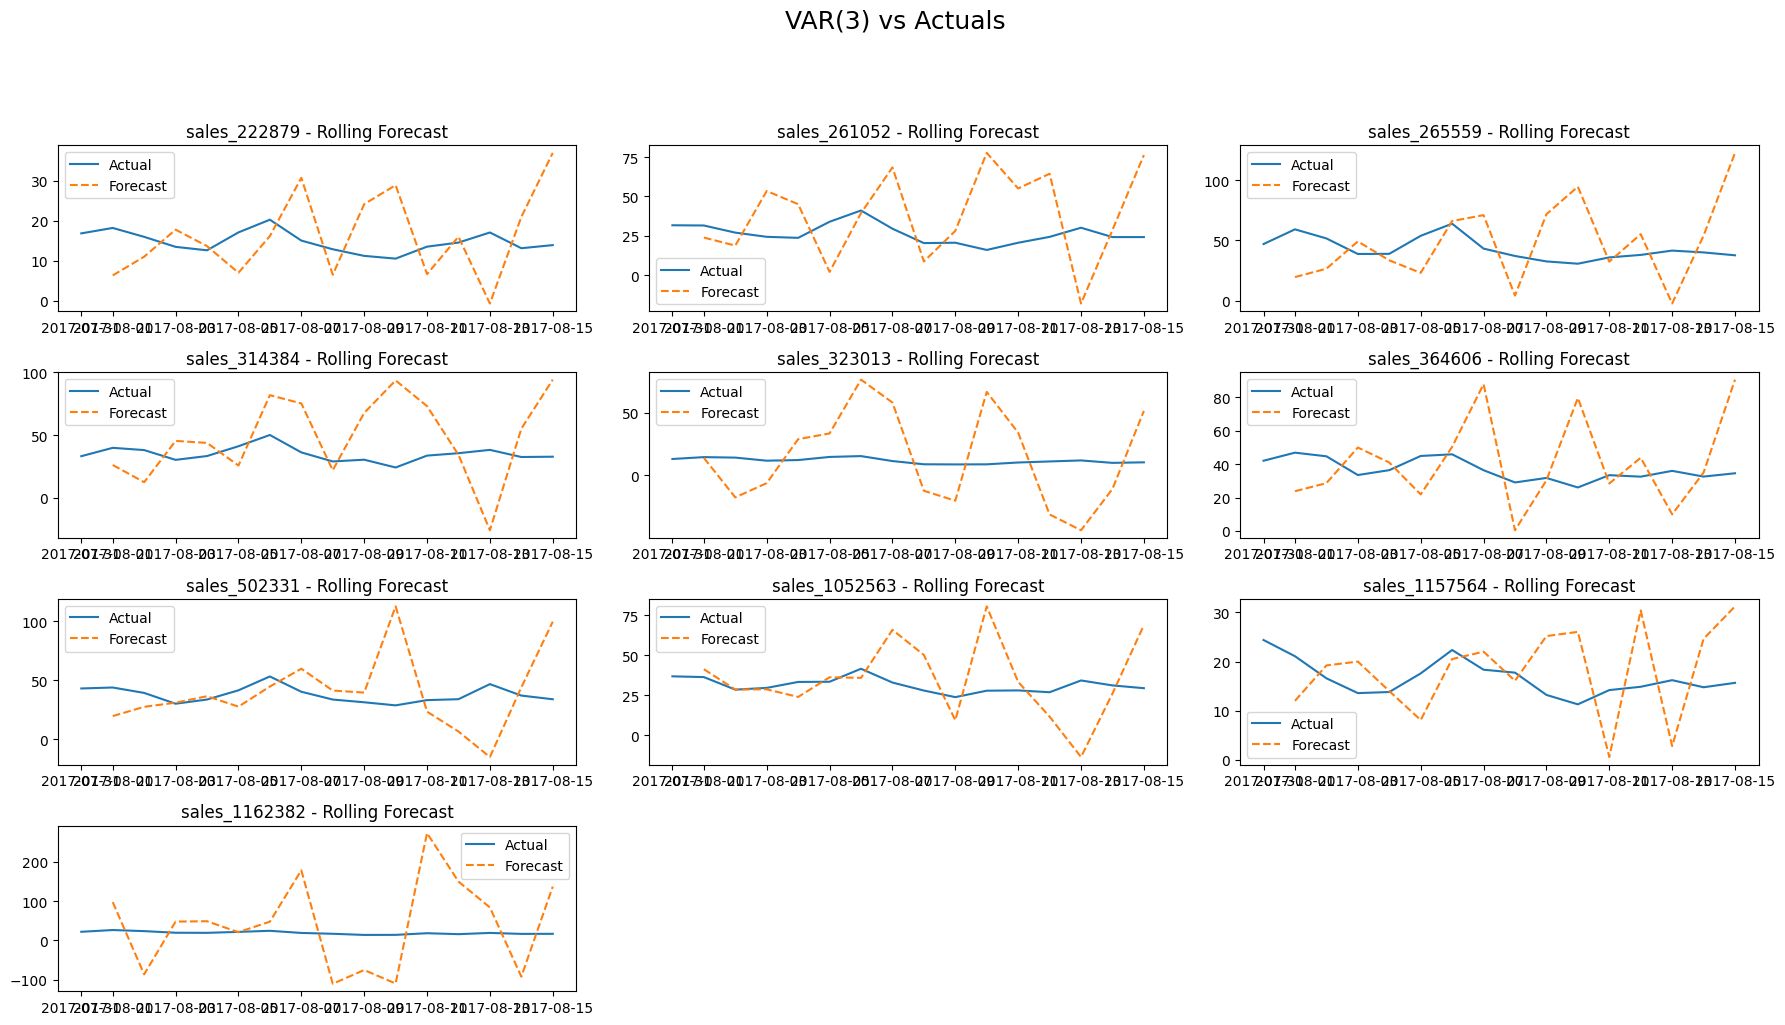

Evaluation metric results: VAR

Metrics for sales_222879:
MSE: 135.99523949785902
MAE: 9.749019028282337
RMSE: 11.661699683059027
MAPE: 69.66287295602277
MSPE: 135.99523949785902
sqrt MSPE: 11.661699683059027
R2: -19.644169840859725

Metrics for sales_261052:
MSE: 1053.433940009595
MAE: 26.599989758746066
RMSE: 32.456647085144134
MAPE: 113.07621895492777
MSPE: 1053.433940009595
sqrt MSPE: 32.456647085144134
R2: -27.304457552588072

Metrics for sales_265559:
MSE: 1365.9178674608165
MAE: 29.44459635381785
RMSE: 36.95832609116404
MAPE: 74.92322135037807
MSPE: 1365.9178674608165
sqrt MSPE: 36.95832609116404
R2: -14.277940737727725

Metrics for sales_314384:
MSE: 1342.4548681048573
MAE: 30.224303374822195
RMSE: 36.63952603548328
MAPE: 91.45051766452241
MSPE: 1342.4548681048573
sqrt MSPE: 36.63952603548328
R2: -37.540640643703725

Metrics for sales_323013:
MSE: 1341.94660853617
MAE: 32.379308886150895
RMSE: 36.632589432582705
MAPE: 288.002422115435
MSPE: 1341.94660853617
sqrt MSPE: 36.632589

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics

plt.figure(figsize=(18, 12))

plt.suptitle('VAR(3) vs Actuals', fontsize=18, y=1.02)

for i, col in enumerate(stock_cols):
    plt.subplot(5, 3, i + 1)
    plt.plot(test_data[col], label="Actual")
    plt.plot(fc_df[col], label="Forecast", linestyle='--')
    plt.title(f"{col} - Rolling Forecast")
    plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for suptitle
plt.show()

from sklearn import metrics

def mean_absolute_percentage_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

def mean_squart_perdiction_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(((y_test - y_pred))**2)

print('Evaluation metric results: VAR')
per_col_results = {}
for col in stock_cols:
    # Align indices explicitly and drop NaN values
    y_true = test_data[col].loc[fc_df.index]
    y_val_pred = fc_df[col]

    # Drop rows where predictions are NaN
    valid_mask = ~y_val_pred.isna()
    y_true = y_true[valid_mask]
    y_val_pred = y_val_pred[valid_mask]

    mse = metrics.mean_squared_error(y_true, y_val_pred)
    mae = metrics.mean_absolute_error(y_true, y_val_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_val_pred)
    mspe = mean_squart_perdiction_error(y_true, y_val_pred)
    r2 = metrics.r2_score(y_true, y_val_pred)

    per_col_results[col] = {
        'mse': mse, 'mae': mae, 'rmse': rmse, 'mape': mape, 'mspe': mspe, 'r2': r2
    }

    print(f"\nMetrics for {col}:")
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MAPE: {mape}')
    print(f'MSPE: {mspe}')
    print(f'sqrt MSPE: {np.sqrt(mspe)}')
    print(f'R2: {r2}')
# Overall metrics across all series
# Drop rows with NaN in predictions
fc_df_clean = fc_df.dropna()
y_true_all = test_data.loc[fc_df_clean.index, stock_cols].values
y_pred_all = fc_df_clean[stock_cols].values
print(f'R2: {r2}')

# Overall metrics across all series (using cleaned data without NaN)
y_true_all = test_data.loc[fc_df_clean.index, stock_cols].values
y_pred_all = fc_df_clean[stock_cols].values

print(f"\nMetrics for VAR model (overall):")
print(f'MSE: {metrics.mean_squared_error(y_true_all, y_pred_all)}')
print(f'MAE: {metrics.mean_absolute_error(y_true_all, y_pred_all)}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_true_all, y_pred_all))}')
print(f'MAPE: {mean_absolute_percentage_error(y_true_all, y_pred_all)}')
print(f'MSPE: {mean_squart_perdiction_error(y_true_all, y_pred_all)}')
print(f'sqrt MSPE: {np.sqrt(mean_squart_perdiction_error(y_true_all, y_pred_all))}')
print(f'R2: {metrics.r2_score(y_true_all, y_pred_all)}')

In [ ]:
var_res = VAR(train_df).fit(best_p)

# In-sample predictions
train_pred = var_res.fittedvalues   # DataFrame
train_true = train_df.iloc[best_p:]  # skip first p lags

print(train_pred.shape, train_true.shape)

from sklearn import metrics
import numpy as np

# Overall training metrics
train_mse = metrics.mean_squared_error(train_true, train_pred)
train_rmse = np.sqrt(train_mse)

print(f"Overall Train MSE: {train_mse:.6f}")
print(f"Overall Train RMSE: {train_rmse:.6f}")

for col in train_true.columns:
    mse = metrics.mean_squared_error(train_true[col], train_pred[col])
    mae = metrics.mean_absolute_error(train_true[col], train_pred[col])
    rmse = np.sqrt(mse)
    print(f"\nMetrics for {col}:")
    print(f"  MSE:  {mse:.6f}")
    print(f"  RMSE: {rmse:.6f}")